# Josue Uriel Martinez Ruiz

#Deep Learning para visión de computadoras
##Lab 1.3 Arquitecturas CNN de referencia: LeNet-5, AlexNet, GoogLeNet y VGG16

**Unidad 1.** Fundamentos de visión por computadora y redes convolucionales
**1.3** Arquitecturas CNN para clasificación

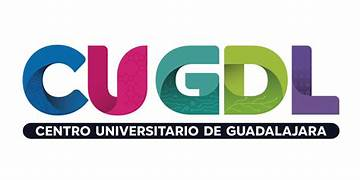

Esta práctica toma como referencia *"Arquitecturas de Redes Convolucionales"* (LeNet-5, AlexNet, GoogLeNet, VGG16), parte A definicion original de los modelos y parte B entrenamiento y evalúación sobre CIFAR-10, para poder comparar capacidad, número de parámetros, tiempo de entrenamiento y desempeño real.

**Objetivos de la práctica**
1. Implementar en PyTorch cuatro arquitecturas CNN clásicas adaptadas a CIFAR-10.
2. Entrenar y evaluar cada una bajo las mismas condiciones (mismos datos, épocas, optimizador).
3. Comparar número de parámetros, tiempo de entrenamiento y accuracy de test.
4. Discutir la relación entre profundidad/capacidad del modelo y su desempeño/eficiencia.

#PARTE A
### Arquitecturas de Redes Convolucionales
En el campo del deep learning y computer vision, una de estas competiciones, que hoy en día ya es un benchmark establecido, es la clasificación de imágenes en el dataset Imagenet. En 2012, la primera red neuronal convolucional entró en esta competición consiguiendo una mejora de 10 puntos sobre la mejor solución hasta la fecha, lo cual supuso un detonante para el campo del deep learning.

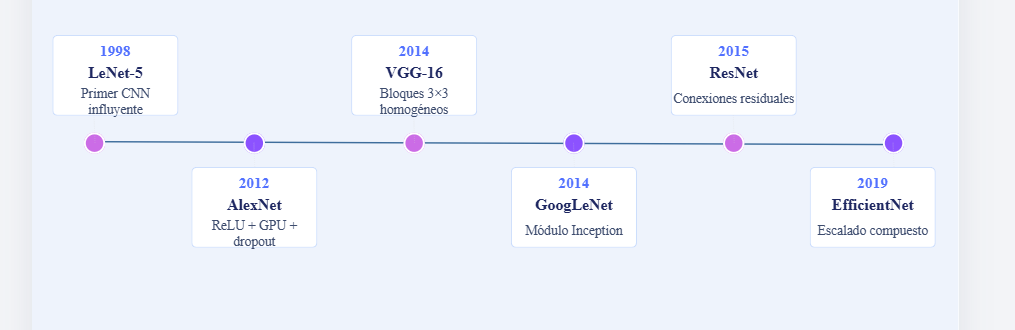

## LeNet-5

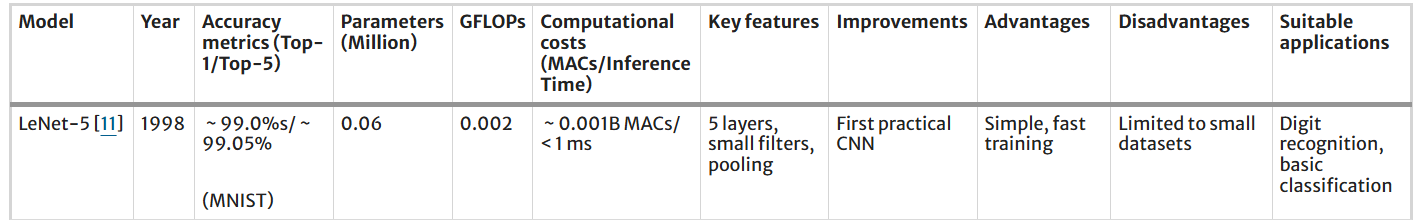

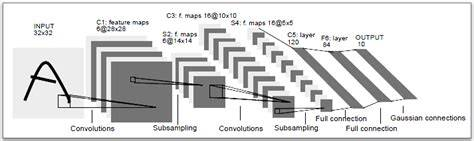

Esta `CNN` es alimentada por imágenes de 32x32 píxeles de dígitos manuscritos, y está formada por tres capas convolucionales, dos de las cuales reducen la dimensionalidad de los mapas de características mediante *average pooling*. La salida de la última capa convolucional es conectada un perceptrón multicapa de dos capas, que tienen la responsabilidad de dar la predicción final. [Artículo de publicación original](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf) . A continuación puedes ver un ejemplo de implementación en `Pytorch`.

In [1]:
import torch

def block(c_in, c_out, k=3, p=1, s=1):
    return torch.nn.Sequential(
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        torch.nn.Tanh(),
        torch.nn.AvgPool2d(2, stride=2)
    )

def block2(c_in, c_out):
    return torch.nn.Sequential(
        torch.nn.Linear(c_in, c_out),
        torch.nn.ReLU()
    )

class LeNet5(torch.nn.Module):
  def __init__(self, n_channels=1, n_outputs=10):
    super().__init__()
    #self.pad = torch.nn.ConstantPad2d(2, 0.)
    self.conv1 = block(n_channels, 6, 5, p=0)
    self.conv2 = block(6, 16, 5, p=0)
    self.conv3 = torch.nn.Sequential(
        torch.nn.Conv2d(16, 120, 5, padding=0),
        torch.nn.Tanh()
    )
    self.fc1 = block2(120, 84)
    self.fc2 = torch.nn.Linear(84, 10)

  def forward(self, x):
    #x = self.pad(x)
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.conv3(x)
    x = x.view(x.shape[0], -1)
    x = self.fc1(x)
    x = self.fc2(x)
    return x

## Actividad
### Ejercicio: Rastreo de dimensiones en LeNet-5

Dada la ejecución del modelo con un lote de entrada aleatorio:

CODE
lenet5 = LeNet5()
output = lenet5(torch.randn(64, 1, 32, 32))
output.shape

**Completa # y ?**

Entrada: (64 , 1, 32, 32) siendo un lote de 64 imágenes.

Conv1 (6 filtros de 5x5 (kernel), stride=1, padding=0): (64, 6, 28, 28)

AvgPool / MaxPool 1 (filtro 2x2, stride=2): (64, 6, 14, 14)

Conv2 (16 filtros de 5x5, stride=1, padding=0): (64, 16, 10, 10)

AvgPool / MaxPool 2 (filtro 2x2, stride=2): (64, 16, 5, 5)

Conv3 (120 filtros de 5x5, stride=1, padding=0): (64, 120, 1, 1)

Aplanamiento (Flatten): (64, 120)

FC1 / Densa 1 (# neuronas): (64, 84)

FC2 / Densa 2 (# neuronas): (64, 10)

Salida final (FC3 / # clases): torch.Size([64, 10])

Demuestra tus resultados con la formula : $O = \left\lfloor \frac{N + 2P - F}{S} \right\rfloor + 1$

N: tamaño espacial de entrada a esa capa. Como tus imágenes son cuadradas, usamos el mismo valor para alto y ancho.

P: padding o relleno. Es cuántos píxeles de ceros se agregan alrededor. Si P=0, no se agrega nada. Si P=1, se agrega 1 píxel por cada lado, por eso aparece 2P.

F: tamaño del filtro o kernel. Si es una convolución 5×5, entonces F=5. Si es un pooling 2×2, entonces F=2.


S: stride o paso. Es cuánto se mueve el filtro. Si S=1, se mueve de 1 en 1. Si S=2, se mueve de 2 en 2.

⌊⋅⌋: redondear hacia abajo. En estos ejemplos da exacto.

O: tamaño espacial de salida, es decir, el nuevo alto/ancho.

In [2]:
lenet5 = LeNet5()
output = lenet5(torch.randn(64, 1, 32, 32))
output.shape

torch.Size([64, 10])

## AlexNet
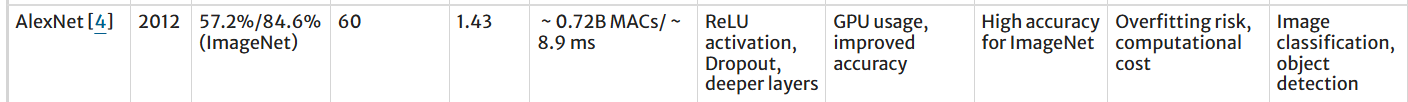



[AlexNet](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf) ganó la competición de Imagenet en 2012. Es una arquitectura similar a LeNet5 pero más profunda. Fue la primera red convolucional que ganó la competición, y también la primera en ser entrenada en GPUs.

![](https://miro.medium.com/fit/c/1838/551/1*arJJYgK-_7VcuKKX1TCKMA.png)

Implementadas en `Pytorch` podemos descargar redes convolucionales con el paquete `torchvision` (en varios paquetes) .

In [3]:
import torchvision
alexnet = torchvision.models.AlexNet()
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

##Actividad
Analiza la siguiente celda de ejecución correspondiente a la arquitectura clásica AlexNet:
cual es el lote de imagenes de entrada canales, dimensiones? y porque su salida es el 1000 indica las lineas de codigo y que representa este numero?

In [4]:
output = alexnet(torch.randn(64, 3, 224, 224))
output.shape

torch.Size([64, 1000])

**Lote de imágenes de entrada, canales y dimensiones**

El tensor de entrada es: `torch.randn(64, 3, 224, 224)`

Significa que la entrada es un lote de 64 imágenes con estas características:
- 64: tamaño del lote (batch size), 64 imágenes a la vez.
- 3: número de canales, como AlexNet fue diseñada para imágenes a color en formato RGB, por esos canales.
- 224: alto de cada imagen.
- 224: ancho de cada imagen.

Entonces, la entrada es:
(64,3,224,224)

Para un lote de 64 imágenes RGB de 224×224 píxeles.

**¿Por qué la salida es 1000?**

La salida de AlexNet es: `torch.Size([64, 1000])`

El 1000 representa el número de clases de salida del modelo, como AlexNet se diseñó originalmente para la competencia ImageNet, que tiene 1000 categorías diferentes, por eso la última capa fully connected tiene 1000 neuronas.

**Interpretación de la salida**

La salida output: (64,1000)
- 64: sigue siendo el tamaño del lote; hay una fila de 1000 valores por cada una de las 64 imágenes.

- 1000: son los logits o puntuaciones para cada una de las 1000 clases de ImageNet. Durante la inferencia, normalmente se aplica softmax para convertirlos en probabilidades.

## VGG
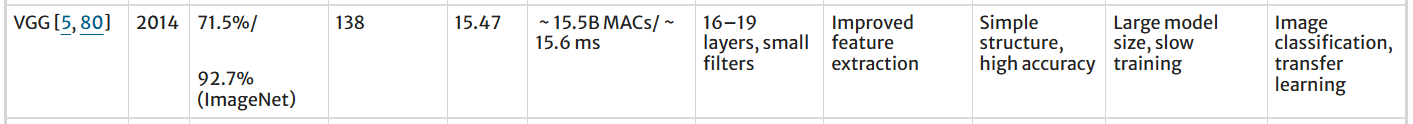



Si bien [VGG](https://arxiv.org/abs/1409.1556) no ganó, tuvo mucho éxito ya que sentó un precedente en el patrón del diseño de las redes convolucionales. Este patrón consiste en usar siempre capas convolucionales con filtros de 3x3, *stride* y *padding* 1 (manteniendo el tamaño de las entradas constante) y usar *max pool* para reducir a la mitad los mapas de características. Además, después de cada capa se dobla el número de filtros.

![](http://jesusutrera.com/articles/img/vgg_model.png)

In [5]:
vgg16 = torchvision.models.vgg16()
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [6]:
 output = vgg16(torch.randn(64, 3, 224, 224))
output.shape

torch.Size([64, 1000])

## Actividad modelos VGG
**Investiga y define en codigo otros modelos de torchvision.models.vgg cuantos hay ya definidos?**

Existen **8 modelos VGG definidos 4 estándar + 4 con BatchNorm**, todos se pueden instanciar de la misma forma, con o sin pesos preentrenados.

Modelo	 Constructor en torchvision	  Descripción

VGG-11	torchvision.models.vgg11()	11 capas con pesos (8 convolucionales + 3 fully connected)

VGG-11-BN	torchvision.models.vgg11_bn()	Igual que VGG-11 pero con capas de Batch Normalization

VGG-13	torchvision.models.vgg13()	13 capas con pesos

VGG-13-BN	torchvision.models.vgg13_bn()	VGG-13 con Batch Normalization

VGG-16	torchvision.models.vgg16()	16 capas con pesos

VGG-16-BN	torchvision.models.vgg16_bn()	VGG-16 con Batch Normalization

VGG-19	torchvision.models.vgg19()	19 capas con pesos

VGG-19-BN	torchvision.models.vgg19_bn()	VGG-19 con Batch Normalization


Fuente: La documentación oficial de PyTorch lista estos 8 constructores: vgg11, vgg11_bn, vgg13, vgg13_bn, vgg16, vgg16_bn, vgg19, vgg19_bn.



## GoogLeNet
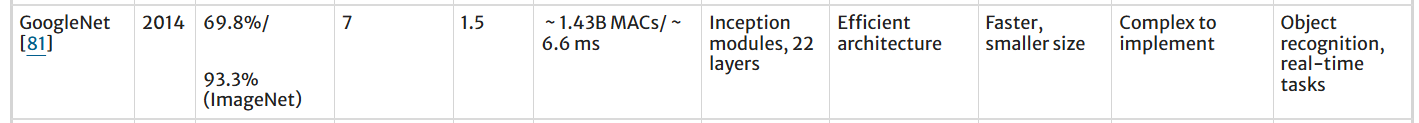



Ganadora de la edición de 2014, GoogLeNet es una red mucho más profunda (podemos empezar a ver la tendencia de que cuantas más capas, mejor resultados). Sus desarrolladores implementaron los módulos *inception*, los cuales aplican diferentes capas convolucionales, con diferentes tamaños de filtros, en paralelo sobre las mismas entradas y luego concatenan las salidas. Además, para poder entrenar esta red tan profunda, se llevan a cabo predicciones en diversas capas intermedias para poder tener gradientes fluyendo hacia las capas iniciales.

![](https://www.alanzucconi.com/wp-content/uploads/2015/07/googlenet-arch.png)

In [7]:
googlenet = torchvision.models.GoogLeNet()
googlenet

c:\Users\josue\anaconda3\envs\pytorch\lib\site-packages\torchvision\models\googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [8]:
output = googlenet(torch.randn(64, 3, 224, 224))
output[0].shape

torch.Size([64, 1000])

## Actividad
**¿Cuántos bloques Inception contiene en total la arquitectura y cómo están agrupados por letras (por ejemplo, a, b, etc.)?**

La arquitectura GoogLeNet contiene un total de 9 bloques Inception, estos bloques no se distribuyen de forma aleatoria, sino que se agrupan en tres etapas o niveles, y se etiquetan con un nombre que combina un número (indica la etapa) y una letra (indica la secuencia dentro de la etapa):

- Etapa 3 (bloques 3a y 3b): Es la primera etapa de bloques Inception, aquí los mapas de características mantienen una resolución espacial de 28x28 píxeles.
- Etapa 4 (bloques 4a, 4b, 4c, 4d y 4e): es la etapa más profunda en cuanto a número de bloques, la resolución espacial se reduce a 14x14 píxeles.
- Etapa 5 (bloques 5a y 5b): Es la etapa final, la resolución de los mapas de características se reduce aún más, a 7x7 píxeles, antes de la clasificación final.

**¿Cuántas ramas convolucionales paralelas procesan la entrada simultáneamente dentro de ese único bloque?**

Dentro de cada bloque Inception, la información de entrada se procesa simultáneamente a través de 4 ramas paralelas (también llamadas caminos o "streams"), en el que cada una de estas ramas está diseñada para extraer características de diferentes escalas espaciales:

1. Rama 1: Aplica una convolución de 1x1.
2. Rama 2: Aplica una convolución de 1x1 seguida de una convolución de 3x3.
3. Rama 3: Aplica una convolución de 1x1 seguida de una convolución de 5x5.
4. Rama 4: Aplica una capa de max-pooling de 3x3, seguida de una convolución de 1x1.

Las convoluciones de 1x1 en las ramas 2 y 3 actúan como cuellos de botella para reducir la dimensionalidad antes de las convoluciones más costosas, lo que disminuye la complejidad computacional del modelo y a l final del bloque, las salidas de las cuatro ramas se concatenan a lo largo de la dimensión de canales.

**Agrega una imagen que lo ejemplifique ¿qué capa de pooling se utiliza en lugar del tradicional aplanamiento masivo (Flatten) que usaban redes como AlexNet o VGG?**

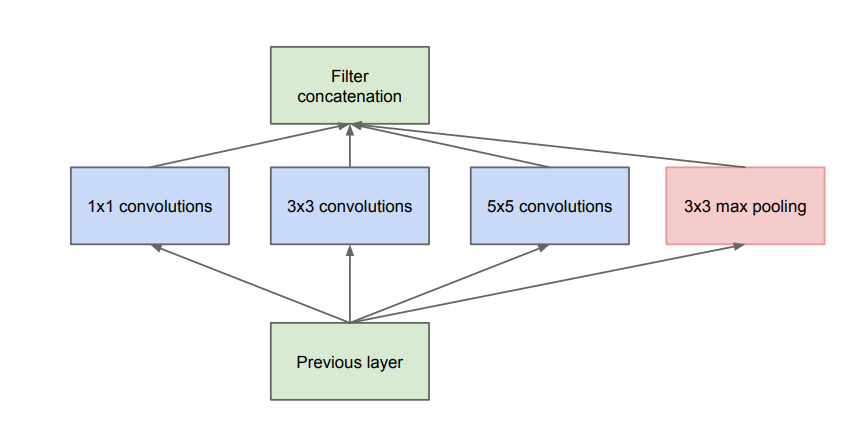

La arquitectura GoogLeNet, en lugar de usar el aplanamiento masivo (Flatten) que conectaba todos los píxeles a una capa densa (como en AlexNet o VGG), utiliza una capa de pooling promedio global (Global Average Pooling) justo antes de la capa de salida.

Esta capa toma el mapa de características final (por ejemplo, de tamaño 7x7x1024) y calcula el promedio de cada canal, generando un vector de 1024 dimensiones. Es decir, colapsa las dimensiones espaciales (alto y ancho) a un solo valor por canal.

**¿Qué ventaja aporta esto al número total de parámetros del modelo?**

El uso de pooling promedio global en lugar de una capa Flatten seguida de capas densas masivas reduce drásticamente el número total de parámetros entrenables del modelo.

- Sin pooling global: Una capa Flatten desde un mapa de 7x7x1024 produciría un vector de 50,176 elementos (7 * 7 * 1024)y poder conectar este vector a una capa densa de 1000 neuronas (como en VGG o AlexNet) implicaría aproximadamente 50 millones de parámetros solo en esa capa (50,176 * 1000).

- Con pooling global: El pooling promedio global reduce esa salida de 7x7x1024 a un vector de solo 1024 elementos y la capa densa final (de 1024 a 1000 clases) solo necesita alrededor de 1 millón de parámetros.

Esta reducción es la razón principal por la que GoogLeNet, a pesar de tener 22 capas, es mucho más compacto, que tiene alrededor de 7 millones de parámetros en total, siendo 9 veces más pequeño que AlexNet y 22 veces más pequeño que VGG.

#PARTE B
**Ajustes respecto a las arquitecturas originales:** las versiones originales de AlexNet y VGG16 fueron diseñadas para imágenes de 224×224 (ImageNet). Entrenarlas tal cual sobre CIFAR-10 (32×32) o reescalando cada imagen a 224×224 sería demasiado costoso. Por eso cada arquitectura se **adapta** aquí para trabajar directamente sobre 32×32 px, manteniendo su estructura conceptual (número y tipo de bloques, filtros, profundidad relativa) pero con canales/strides ajustados. Esto es intencional: la comparación de "capacidad versus eficiencia"

> 💡El dataset Imagenet contiene imágenes comunes descargadas de internet, y el objetivo es el de clasificar imágenes entre 1000 clases diferentes. Es por este motivo que verás que los diferentes modelos en `torchvision` tienen una última capa lineal con 1000 salidas.

## 1. Configuración e importaciones

In [9]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


ModuleNotFoundError: No module named 'matplotlib'

## 2. Carga y preprocesamiento de CIFAR-10

Se usa CIFAR-10 (60,000 imágenes de 32×32 px a color, 10 clases) tal como indica el programa de la asignatura. Se separa un subconjunto de validación a partir del set de entrenamiento.

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

full_train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

val_fraction = 0.1
val_size = int(len(full_train_set) * val_fraction)
train_size = len(full_train_set) - val_size
train_set, val_set = random_split(full_train_set, [train_size, val_size], generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ("avión", "automóvil", "pájaro", "gato", "venado", "perro", "rana", "caballo", "barco", "camión")
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")


In [ ]:
# Vista rápida de algunas imágenes del dataset
def imshow(img):
    img = img * torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1) + torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(npimg.transpose(1, 2, 0).clip(0, 1))

sample_loader = DataLoader(test_set, batch_size=8, shuffle=True)
images, labels = next(iter(sample_loader))
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow((images[i] * torch.tensor([0.2470,0.2435,0.2616]).view(3,1,1) + torch.tensor([0.4914,0.4822,0.4465]).view(3,1,1)).permute(1,2,0).clip(0,1))
    ax.set_title(classes[labels[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Arquitecturas

Se implementan cuatro arquitecturas, cada una en su propia celda, con un breve comentario sobre su idea central y el ajuste realizado para CIFAR-10.

### 3.1 LeNet-5 (LeCun et al., 1998)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

In [ ]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5, padding=2),   # 32x32 -> 32x32
            nn.Tanh(),
            nn.AvgPool2d(2),                              # -> 16x16
            nn.Conv2d(6, 16, kernel_size=5),               # -> 12x12
            nn.Tanh(),
            nn.AvgPool2d(2),                               # -> 6x6
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 6 * 6, 120), nn.Tanh(),
            nn.Linear(120, 84), nn.Tanh(),
            nn.Linear(84, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


La adaptación de LeNet-5 para CIFAR-10 introduce tres cambios clave respecto a la versión original:
1. La entrada pasa de 1 canal (escala de grises, 32×32) a 3 canales (RGB), ya que CIFAR-10 contiene imágenes a color.
2. Se añade padding=2 en la primera convolución para conservar el tamaño espacial de 32×32 (en lugar de reducirlo a 28×28), lo que permite que tras dos bloques de pooling se llegue a un mapa de 6×6.
3. Se elimina la tercera capa convolucional (la Conv3 de 120 filtros 5×5 que en el original colapsaba el mapa a 1×1) y se sustituye por un Flatten directo desde 16×6×6 = 576 características hacia la primera capa densa.

El clasificador se mantiene idéntico en su estructura (120 → 84 → 10) y se conserva el uso de Tanh como activación, fiel al diseño original de LeCun.

En conjunto, la versión adaptada es más simple en profundidad pero funcional para entradas RGB de 32×32, manteniendo la esencia del diseño original.

### 3.2 AlexNet adaptado (Krizhevsky et al., 2012)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

In [ ]:
class AlexNetAdaptado(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 16x16
            nn.Conv2d(64, 192, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 8x8
            nn.Conv2d(192, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512), nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


La adaptación de AlexNet para CIFAR-10 reduce drásticamente la escala de la red para ajustarse a imágenes de 32×32 en lugar de las 224×224 del original, mientras que la AlexNet original comienza con una convolución de 11×11 con stride=4 y utiliza kernels de 5×5, la versión adaptada emplea únicamente convoluciones de 3×3 con padding=1, lo que permite conservar mejor la resolución en imágenes pequeñas y extraer características más finas.

También se sustituye el max-pooling de 3×3 con stride=2 (solapado) por un max-pooling de 2×2 con stride=2 (no solapado), y se eliminan las capas de normalización por respuesta local (LRN) y la división de la red en dos GPUs.

El clasificador original de tres capas densas de 4096 → 4096 → 1000 se reemplaza por uno mucho más compacto de 1024 → 512 → 10, manteniendo el uso de ReLU y Dropout (0.5).

En conjunto, la arquitectura adaptada conserva la idea central de AlexNet (cinco convoluciones + tres capas densas) pero con menos parámetros y kernels más pequeños, haciéndola viable para CIFAR-10.

### 3.3 VGG16 adaptado (Simonyan & Zisserman, 2014)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

In [ ]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs):
        super().__init__()
        layers = []
        for i in range(num_convs):
            in_c = in_channels if i == 0 else out_channels
            layers += [nn.Conv2d(in_c, out_channels, kernel_size=3, padding=1), nn.ReLU(inplace=True)]
        layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class VGG16Adaptado(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            VGGBlock(3, 32, 2),     # 32x32 -> 16x16
            VGGBlock(32, 64, 2),    # -> 8x8
            VGGBlock(64, 128, 3),   # -> 4x4
            VGGBlock(128, 256, 3),  # -> 2x2
            VGGBlock(256, 256, 3),  # -> 1x1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 1 * 1, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


La adaptación de VGG16 para CIFAR-10 mantiene la estructura modular por bloques característica de VGG (varias convoluciones 3×3 seguidas de un max-pooling), pero reduce drásticamente el número de canales en cada bloque:

En lugar de la progresión original 64 → 128 → 256 → 512 → 512, la versión adaptada usa 32 → 64 → 128 → 256 → 256, lo cual es necesario porque las imágenes de entrada son de 32×32 en vez de 224×224, y tras cinco max-poolings el mapa queda en 1×1.

El clasificador original de VGG16, con tres capas densas de 4096 → 4096 → 1000, se reemplaza por uno mucho más ligero de 512 → 10 con un solo Dropout, reduciendo drásticamente los parámetros (de ~138M a unos pocos millones). Se conservan las ideas clave: kernels 3×3 con padding=1, ReLU, max-pooling 2×2 y la agrupación en bloques, pero la red queda adaptada a la escala y al número de clases de CIFAR-10.

### 3.4 GoogLeNet mini (Szegedy et al., 2014)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

In [ ]:
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, ch1x1, kernel_size=1), nn.ReLU(inplace=True))
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, ch3x3red, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(ch3x3red, ch3x3, kernel_size=3, padding=1), nn.ReLU(inplace=True))
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, ch5x5red, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(ch5x5red, ch5x5, kernel_size=5, padding=2), nn.ReLU(inplace=True))
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1), nn.ReLU(inplace=True))

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)


class GoogLeNetMini(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                    # -> 16x16
        )
        self.inception1 = InceptionBlock(64, 32, 32, 64, 8, 16, 16)     # out = 128
        self.inception2 = InceptionBlock(128, 64, 64, 96, 16, 32, 32)   # out = 224
        self.pool = nn.MaxPool2d(2)                                     # -> 8x8
        self.inception3 = InceptionBlock(224, 96, 64, 128, 16, 32, 32)  # out = 288
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(288, num_classes))

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.pool(x)
        x = self.inception3(x)
        x = self.global_pool(x)
        return self.classifier(x)


La GoogLeNetMini adaptada para CIFAR-10 conserva la idea central del bloque Inception con sus cuatro ramas paralelas (1×1, 1×1+3×3, 1×1+5×5 y maxpool+1×1), pero reduce drásticamente la arquitectura original: pasa de 9 bloques Inception (etapas 3a, 3b, 4a–4e, 5a, 5b) a solo 3 bloques, elimina los dos clasificadores auxiliares, simplifica el stem a una única convolución 3×3 + maxpool (en lugar de la secuencia más profunda del original) y reduce los canales de salida de cada bloque (128, 224, 288 frente a los 256–1024 del original).

También ajusta la entrada de 224×224 a 32×32 y reemplaza el clasificador final de 1024 → 1000 por una capa lineal de 288 → 10, manteniendo el global average pooling y el dropout (0.4).

Es una versión muy compacta y viable para CIFAR-10, pero conserva la esencia del diseño Inception.

## 4. Funciones genéricas de entrenamiento y evaluación

Las mismas funciones se usan para las cuatro arquitecturas, para que la comparación final sea justa.

## Actividad
Define hiperparámetros de entrenamiento y optimizador

In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(model, train_loader, val_loader, epochs=8, lr=1e-3, name="modelo"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                v_loss += loss.item() * x.size(0)
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += x.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{name}] Época {epoch+1}/{epochs} - "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    elapsed = time.time() - start
    print(f"[{name}] Tiempo total de entrenamiento: {elapsed:.1f} s")
    return history, elapsed


def evaluate_test(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return correct / total


In [ ]:
#Hiperparámetros para las 4 arquitecturas
EPOCHS = 8
LR = 1e-3
OPTIMIZER = "Adam"
LOSS = "CrossEntropyLoss"
SEED = 42

## 5. Entrenamiento de las cuatro arquitecturas

`EPOCHS` Una buena práctica es configurar un bajo numero. Si el tiempo lo permite, se puede subir a 15–20 épocas para ver mejor las diferencias de convergencia.

In [ ]:

modelos = {
    "LeNet-5": LeNet5(),
    "AlexNet (adaptado)": AlexNetAdaptado(),
    "GoogLeNet (mini)": GoogLeNetMini(),
    "VGG16 (adaptado)": VGG16Adaptado(),
}

historiales = {}
resultados = {}

for nombre, modelo in modelos.items():
    print(f"\n=== Entrenando {nombre} ===")
    n_params = count_params(modelo)
    print(f"Parámetros entrenables: {n_params:,}")
    hist, tiempo = train_model(modelo, train_loader, val_loader, epochs=EPOCHS, name=nombre)
    test_acc = evaluate_test(modelo, test_loader)
    print(f"[{nombre}] Accuracy en test: {test_acc:.4f}")

    historiales[nombre] = hist
    resultados[nombre] = {
        "parametros": n_params,
        "tiempo_entrenamiento_s": round(tiempo, 1),
        "val_acc_final": round(hist["val_acc"][-1], 4),
        "test_accuracy": round(test_acc, 4),
    }


## 6. Comparación de resultados

In [ ]:
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values("test_accuracy", ascending=False)
df_resultados


In [ ]:
plt.figure(figsize=(10, 5))
for nombre, hist in historiales.items():
    plt.plot(range(1, EPOCHS + 1), hist["val_acc"], marker="o", label=nombre)
plt.xlabel("Época")
plt.ylabel("Accuracy de validación")
plt.title("Comparación de arquitecturas — Accuracy de validación por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(10, 5))
for nombre, hist in historiales.items():
    plt.plot(range(1, EPOCHS + 1), hist["val_loss"], marker="o", label=nombre)
plt.xlabel("Época")
plt.ylabel("Pérdida de validación")
plt.title("Comparación de arquitecturas — Pérdida de validación por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(df_resultados.index, df_resultados["parametros"] / 1e6)
plt.ylabel("Parámetros entrenables (millones)")
plt.title("Número de parámetros por arquitectura")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 7. Preguntas de reflexión (para responder en la bitácora)

1. **¿Qué arquitectura obtuvo el mejor accuracy de test? ¿Es también la que más parámetros tiene o la más rápida de entrenar?**

AlexNet (adaptado) obtuvo el mejor accuracy de test con 0.7476 (74.76%).

- Sí es la que más parámetros tiene: 6,976,842 (~7M), casi el doble que VGG16 y ~84 veces más que LeNet-5.
- Pero no es la más rápida: LeNet-5 fue la más rápida (156.6 s), seguida muy de cerca por AlexNet (166.1 s), la diferencia es de solo ~10 s, lo cual es sorprendente dado que AlexNet tiene 84 veces más parámetros.

Conclusión: el mejor rendimiento vino acompañado de la mayor capacidad, pero el costo en tiempo fue relativamente bajo (probablemente porque el dataset es pequeño y las convoluciones son de 3×3, más eficientes que las 11×11 del original).

2. **Compara LeNet-5 contra las otras tres: ¿qué tanto mejora el accuracy al aumentar la profundidad/capacidad del modelo, y a qué costo (tiempo, parámetros)?**

LeNet-5 obtuvo un test accuracy de 0.5408 (54.08 %) y las otras arquitecturas:

| Modelo | Test accuracy | Mejora vs LeNet-5 | Parámetros | Veces los parámetros de LeNet-5 | Tiempo (s) |
|---|---:|---:|---:|---:|---:|
| LeNet-5 | 0.5408 | — | 83,126 | 1× | 156.6 |
| GoogLeNet (mini) | 0.6518 | +11.10 pp | 256,530 | ~3.1× | 172.7 |
| VGG16 (adaptado) | 0.6477 | +10.69 pp | 3,816,874 | ~45.9× | 170.3 |
| AlexNet (adaptado) | 0.7476 | +20.68 pp | 6,976,842 | ~83.9× | 166.1 |

La mejora al aumentar profundidad/capacidad es clara, pero no es proporcional al número de parámetros.

  - GoogLeNet mini y VGG16 mejoran alrededor de 11 puntos porcentuales con costos de parámetros muy distintos: GoogLeNet usa ~0.26 M y VGG16 ~3.8 M.
  - AlexNet logra la mayor mejora (+20.68 pp), pero a costa de ~7 M de parámetros.

En tiempo, las cuatro arquitecturas tardan valores similares (156–173 s), así que el costo principal se ve en cantidad de parámetros, no tanto en tiempo de entrenamiento en este entorno.

3. **GoogLeNet mini usa módulos Inception (varias convoluciones en paralelo) en vez de solo apilar capas como VGG16. ¿Se refleja esa diferencia de diseño en los resultados obtenidos aquí?**

Sí, aunque de forma moderada, GoogLeNet mini obtuvo 0.6518 de test accuracy, ligeramente superior a VGG16 adaptado, que obtuvo 0.6477, la diferencia es muy pequeña: 0.41 puntos porcentuales.

Lo más destacable es la eficiencia en parámetros: GoogLeNet mini logra un accuracy similar usando 256,530 parámetros, mientras que VGG16 necesita 3,816,874 parámetros (unas 15 veces más).

Esto refleja la ventaja del diseño Inception: extraer características a varias escalas en paralelo permite un modelo más compacto, mas sin embargo en esta versión mini y con solo 8 épocas, esa ventaja no se traduce en un accuracy muy superior; ambos quedan por debajo de AlexNet adaptado.

4. **Si tuvieras que desplegar un modelo de clasificación de imágenes en un dispositivo con recursos limitados (por ejemplo, una cámara industrial), ¿cuál de estas cuatro arquitecturas elegirías y por qué? Relaciona tu respuesta con el criterio de "capacidad versus eficiencia".**

Elegiría GoogLeNet mini, por que es el modelo que ofrece el mejor equilibrio capacidad–eficiencia para recursos limitados: con solo 256,530 parámetros alcanza un 65.18 % de accuracy en test, muy por encima de LeNet-5 (54.08 %) y prácticamente igual que VGG16 (64.77 %), pero usando ~15 veces menos parámetros que VGG16 y ~27 veces menos que AlexNet.

LeNet-5 es aún más pequeño y rápido, pero su accuracy es notablemente inferior, lo que podría no ser suficiente en una tarea industrial real.
AlexNet da el mejor accuracy, pero con ~7 M de parámetros es más pesado para un dispositivo embebido.

Por lo tanto, si el recurso es limitado y se busca un buen compromiso, GoogLeNet mini es la opción más razonable, y si la precisión fuera crítica y hubiera más recursos, AlexNet; si el dispositivo fuera extremadamente limitado y se aceptara menor precisión, LeNet-5.

5. **¿Qué esperarías que pasara con estas cuatro arquitecturas si se entrenaran 30 epocas? ¿Cambiaría?**

Con 30 épocas, lo más probable es que:
- AlexNet (adaptado) siga mejorando o se estanque, pero con mayor riesgo de sobreajuste si no se añade regularización adicional y podría mantener el mejor accuracy, aunque la ganancia sobre 8 épocas sería cada vez menor.
- VGG16 (adaptado) probablemente siga mejorando, porque en las curvas se ve que todavía estaba aprendiendo y su pérdida de validación seguía bajando. Podría acercarse o superar a GoogLeNet mini e incluso competir con AlexNet.
- GoogLeNet mini también podría mejorar, pero al ser una versión muy reducida, su capacidad podría saturarse antes, que podría beneficiarse de más épocas, aunque con riesgo de sobreajuste.
- LeNet-5 probablemente se estanque pronto, su baja capacidad limita cuánto puede mejorar; es posible que aumente poco o que empiece a sobreajustar sin ganar accuracy de test.

En resumen, sí cambiarían los resultados, sobre todo para VGG16 y AlexNet, pero las mejoras serían decrecientes. El ranking entre VGG16 y GoogLeNet mini podría cambiar, y AlexNet probablemente seguiría siendo el más preciso, aunque con mayor costo computacional. Para aprovechar 30 épocas convendría usar early stopping, scheduler de learning rate y regularización (dropout, weight decay, data augmentation) para evitar sobreajuste.



## 8. Entrega

Subir este notebook ejecutado (con las salidas de las celdas visibles) al GitHub personal (publico) crear una carpeta para el curso, en subcarpeta correspondiente a la Unidad 1 / Práctica 3.

Subir en formato PDF a Classroom  + Anexar link de repositorio